# Function approximation with PyTorch
# Testing boundaries of ML

---



The objective of this tutorial is learn the basics of PyTorch.

To this end, we cosider the task of learning the function

$$u = sin(x), \quad x\in(0, 2\pi)$$

by using feed-forward dense neural networks.

-----

While the above is the objective of the tutorial, additional testing on following features will be carried out to understand concept:
1. Replicate baseline requirement.
2. How much data does the Neural Network required?
3. Impact of noise on the learning.
4. Change architecture of underlying neural net?
5. Model overfitting
6. Test-Train-Validate split difference
7. Various activation functions
8. Data point outside training set?


In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

$\mathbf{\text{Step 1: Data generation}}$

In [48]:
def generate_data(num_points, x_start, x_end, noise_std=0.1):
  # Generate synthetic dataset for analysis.
  # Include noise with the generate data.
  x = np.random.uniform(x_start, x_end, num_points)
  x = np.sort(x)
  y = np.sin(x) + np.random.normal(0, noise_std, num_points)
  return x, y

In [49]:
num_points = 1000
x_data_start = 0
x_data_end   = 2*np.pi
x_train, y_train = generate_data(num_points, x_data_start, x_data_end, noise_std=0.1)

$\mathbf{\text{Step 2: Model Definition}}$


In [50]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(1, 10)  # 1 input feature, 10 hidden units
        self.activation = nn.SiLU()
        self.fc2 = nn.Linear(10, 1)  # 10 hidden units, 1 output

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

$\mathbf{\text{Step 3: Model Training}}$


In [51]:
def get_optimizer(optimizer_name, model):
  if optimizer_name == "ADAM":
      return optim.Adam(model.parameters())
  elif optimizer_name == "LBFGS":
      return optim.LBFGS(model.parameters())
  raise ValueError('Chosen optimizer is unavailable.')

def train(model, optimizer, criterion, inputs, targets):
    def closure():
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        return loss

    optimizer.step(closure)
    return closure().item()

def evaluate(model, x_test):
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test.view(-1, 1)).numpy()
    return y_pred

In [52]:
model = SimpleNN()
criterion = nn.MSELoss()
optimizer = get_optimizer('ADAM', model)

num_epochs = 10000
for epoch in range(num_epochs):
    # Convert data to PyTorch tensors
    inputs = torch.tensor(
        x_train, dtype=torch.float32, requires_grad=True).view(-1, 1)
    targets = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    # Training
    loss = train(model, optimizer, criterion, inputs, targets)

    if (epoch+1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}')

Epoch [1000/10000], Loss: 0.1303
Epoch [2000/10000], Loss: 0.0903
Epoch [3000/10000], Loss: 0.0433
Epoch [4000/10000], Loss: 0.0167
Epoch [5000/10000], Loss: 0.0110
Epoch [6000/10000], Loss: 0.0107
Epoch [7000/10000], Loss: 0.0107
Epoch [8000/10000], Loss: 0.0107
Epoch [9000/10000], Loss: 0.0107
Epoch [10000/10000], Loss: 0.0107


$\mathbf{\text{Step 4: Plotting Predictions}}$


Final step, evaluate your predictions at some input locations and do some plotting.


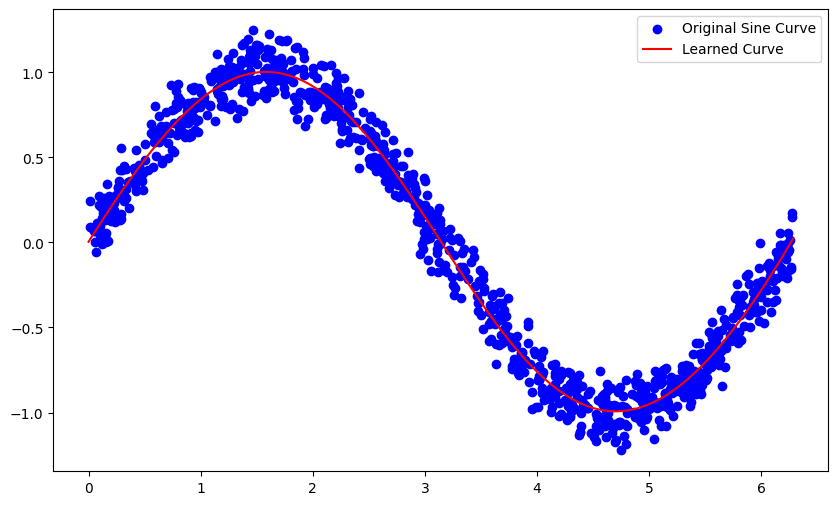

In [26]:
x_test = torch.linspace(0, 2*np.pi, 100)
y_pred = evaluate(model, x_test)

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, label='Original data Curve', color='blue')
plt.plot(x_test, y_pred, label='Learned Sine Curve', color='red')

plt.legend()
plt.show()

# How much data does NN require?

Try with data set having 10, 25, 50, 100, 250, 500, 750, 1000 points.

In [63]:
x_data_start = -2*np.pi
x_data_end   = 2*np.pi

In [67]:
# Dataset sizes to compare
data_sizes = [10, 25, 50, 100, 250, 500, 750, 1000]

# Predefined test set to ensure all comparison is on same data
x_test = torch.linspace(x_data_start, x_data_end, data_sizes[-1])
y_test = torch.sin(x_test)

test_mse = []
predictions = []
training_data = []

for num_points in data_sizes:
    # Generate training data
    x_train, y_train = generate_data(num_points,x_data_start,x_data_end,noise_std=0.1)

    # Convert to tensors ONCE
    inputs = torch.tensor(x_train, dtype=torch.float32).view(-1, 1)
    targets = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    # Create model
    model = SimpleNN()
    criterion = nn.MSELoss()
    optimizer = get_optimizer('ADAM', model)

    # Train
    num_epochs = 10000

    for epoch in range(num_epochs):
        loss = train(model, optimizer, criterion, inputs, targets)

    # Evaluation
    y_pred = evaluate(model, x_test)

    # Test MSE against TRUE sine
    mse = np.mean((y_pred.flatten() - y_test.numpy())**2)
    test_mse.append(mse)
    predictions.append(y_pred)
    training_data.append((x_train, y_train))

    print(f"N = {num_points:4d} | " f"Training loss = {loss:.5f} | " f"Test MSE = {mse:.5f}")

N =   10 | Training loss = 0.00210 | Test MSE = 0.50501
N =   25 | Training loss = 0.00689 | Test MSE = 0.00354
N =   50 | Training loss = 0.00788 | Test MSE = 0.00232
N =  100 | Training loss = 0.00872 | Test MSE = 0.00116
N =  250 | Training loss = 0.01035 | Test MSE = 0.00203
N =  500 | Training loss = 0.04831 | Test MSE = 0.04528
N =  750 | Training loss = 0.01014 | Test MSE = 0.00017
N = 1000 | Training loss = 0.00978 | Test MSE = 0.00040


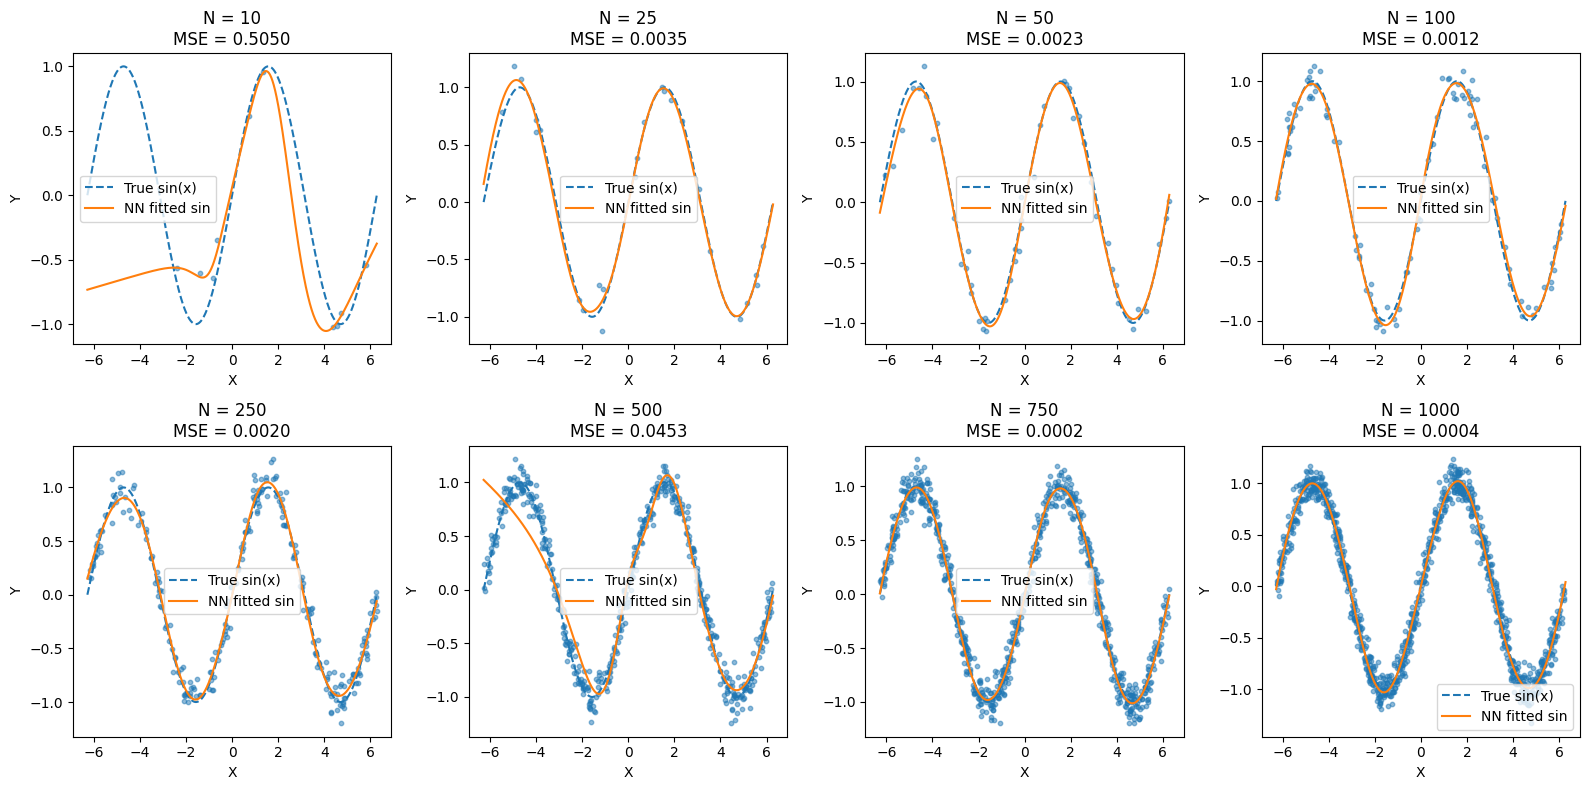

In [68]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, num_points in enumerate(data_sizes):
    ax = axes.flat[i]
    x_train, y_train = training_data[i]

    # Training data
    ax.scatter(x_train, y_train, s=10, alpha=0.5)
    # True function
    ax.plot(x_test, y_test, '--', label="True sin(x)")

    # NN prediction
    ax.plot(x_test, predictions[i], label="NN fitted sin")

    ax.set_title(f"N = {num_points}\nMSE = {test_mse[i]:.4f}")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend()

plt.tight_layout()
plt.show()

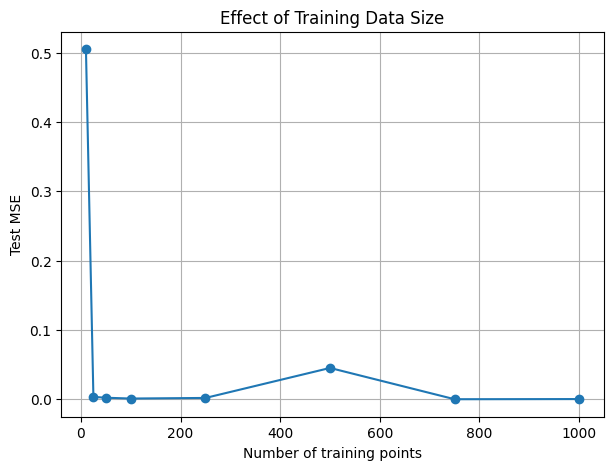

In [69]:
plt.figure(figsize=(7, 5))

plt.plot(data_sizes, test_mse, "o-")

plt.xlabel("Number of training points")
plt.ylabel("Test MSE")
plt.title("Effect of Training Data Size")

plt.grid()
plt.show()

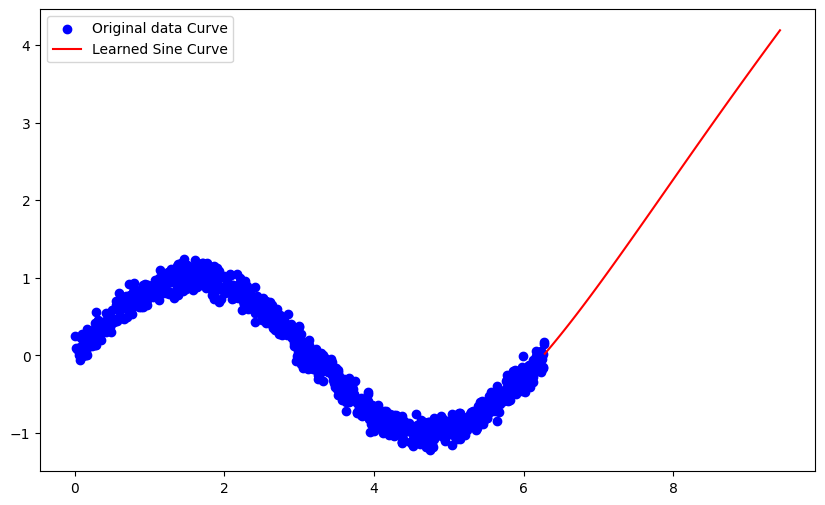

In [28]:
# What happens when my input feature is outside the training dataset?
# 0 to 2PI is our training set. How about predictions between 2PI to 3PI

x_test = torch.linspace(2*np.pi, 3*np.pi, 100)
y_pred = evaluate(model, x_test)

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, label='Original data Curve', color='blue')
plt.plot(x_test, y_pred, label='Learned Sine Curve', color='red')

plt.legend()
plt.show()

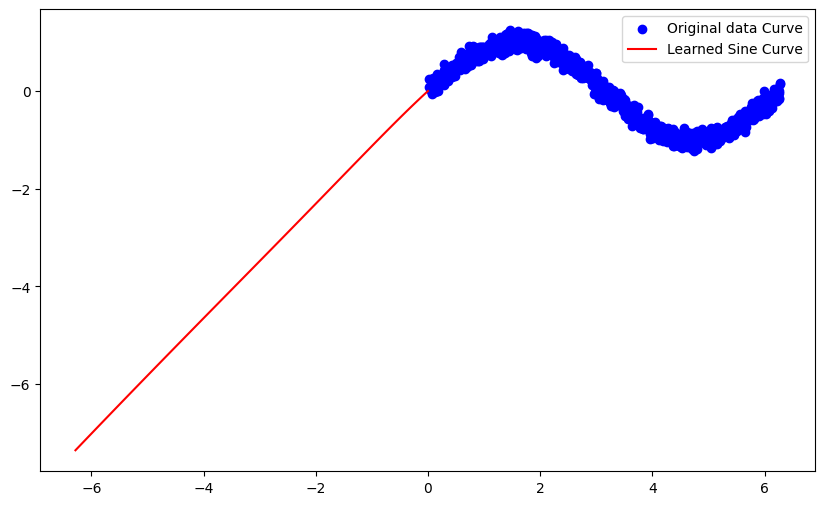

In [29]:
# What happens when my input feature is outside the training dataset?
# 0 to 2PI is our training set. How about predictions between -2PI to 0PI

x_test = torch.linspace(-2*np.pi, 0*np.pi, 100)
y_pred = evaluate(model, x_test)

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, label='Original data Curve', color='blue')
plt.plot(x_test, y_pred, label='Learned Sine Curve', color='red')

plt.legend()
plt.show()